## Quantium Virtual Internship 

# Quantium Data Analytics Virtual Internship — Chip Category Analysis

## Business Context
Quantium is supporting a retail client's strategic planning for the chips 
category. This notebook analyzes customer purchasing behavior and evaluates 
the impact of a new store layout trialed in three stores.

## Objectives
1. Identify what drives chip category sales — customer segments, brands, 
   pack sizes, and seasonal trends
2. Select appropriate control stores and assess whether a new store layout 
   trial produced a statistically significant sales increase

## Structure of this notebook
- Data Cleaning
- Category & Customer Analysis  
- Trial Store Selection (Control Store Matching)
- Trial Impact Assessment (Significance Testing)
- Key Insights & Recommendations

In [1]:
!pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Installing libraries
import pandas as pd
import numpy as np 

In [3]:
# Loading datasets

df_transaction = pd.read_excel("QVI_transaction_data.xlsx")
df_purchase_behaviour = pd.read_csv("QVI_purchase_behaviour.csv")

In [4]:
# Examining Transaction data 
df_transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
df_transaction['DATE'] = pd.read_excel("QVI_transaction_data.xlsx", usecols=['DATE'])['DATE']

In [6]:
df_transaction['DATE'] = pd.to_datetime(df_transaction['DATE'], unit='D', origin='1899-12-30')

In [7]:
df_transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
df_transaction.shape

(264836, 8)

In [9]:
# Checking for inconsistencies and null values
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


In [10]:
df_transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


# Datasets contains outliers as their is a big jump between 75th Percentile and Max 

In [11]:
df_transaction[df_transaction['PROD_QTY'] > 100]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [12]:
# Removing Outliers 
outlier_card = 226000

df_transaction = df_transaction[df_transaction['LYLTY_CARD_NBR'] != outlier_card]

In [13]:
df_transaction.shape

(264834, 8)

In [14]:
## Feature Engineering
# Extracting the weight from the PROD_NAME into a new column
df_transaction['PACK_SIZE'] = df_transaction['PROD_NAME'].str.extract(r'(\d+)[gG]')

In [15]:
df_transaction['PACK_SIZE'] = df_transaction['PACK_SIZE'].astype(int)

In [16]:
# Removing the weight from the PROD_NAME as it is now in a new column
df_transaction['PROD_NAME'] = df_transaction['PROD_NAME'].str.replace(r'\s*\d+[Gg]', '' , regex=True).str.strip()

In [17]:
df_transaction['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt', 'CCs Nacho Cheese',
       'Smiths Crinkle Cut  Chips Chicken',
       'Smiths Chip Thinly  S/Cream&Onion',
       'Kettle Tortilla ChpsHny&Jlpno Chili',
       'Old El Paso Salsa   Dip Tomato Mild',
       'Smiths Crinkle Chips Salt & Vinegar',
       'Grain Waves         Sweet Chilli',
       'Doritos Corn Chip Mexican Jalapeno',
       'Grain Waves Sour    Cream&Chives',
       'Kettle Sensations   Siracha Lime', 'Twisties Cheese',
       'WW Crinkle Cut      Chicken', 'Thins Chips Light&  Tangy',
       'CCs Original', 'Burger Rings',
       'NCC Sour Cream &    Garden Chives',
       'Doritos Corn Chip Southern Chicken', 'Cheezels Cheese Box',
       'Smiths Crinkle      Original',
       'Infzns Crn Crnchers Tangy Gcamole',
       'Kettle Sea Salt     And Vinegar',
       'Smiths Chip Thinly  Cut Original', 'Kettle Original',
       'Red Rock Deli Thai  Chilli&Lime', 'Pringles Sthrn FriedChicken',
       'Pringles Sweet&Spcy BBQ', 'Red

In [18]:
# Category check
non_chip_mask = df_transaction['PROD_NAME'].str.contains(
    'Old El Paso|Woolworths.*Salsa|Doritos Salsa', case=False, na=False
)
print(df_transaction[non_chip_mask]['PROD_NAME'].unique())
print(non_chip_mask.sum())

['Old El Paso Salsa   Dip Tomato Mild' 'Doritos Salsa       Medium'
 'Old El Paso Salsa   Dip Chnky Tom Ht' 'Woolworths Mild     Salsa'
 'Old El Paso Salsa   Dip Tomato Med' 'Woolworths Medium   Salsa'
 'Doritos Salsa Mild']
15166


In [19]:
df_transaction = df_transaction[~non_chip_mask]
print(df_transaction.shape)

(249668, 9)


## Examning Customers Data 

In [20]:
df_purchase_behaviour.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [21]:
df_purchase_behaviour.shape

(72637, 3)

In [22]:
len(df_purchase_behaviour['LYLTY_CARD_NBR'].unique())

72637

In [23]:
df_purchase_behaviour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [24]:
df_purchase_behaviour.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [25]:
df_purchase_behaviour['LIFESTAGE'].unique()

array(['YOUNG SINGLES/COUPLES', 'YOUNG FAMILIES', 'OLDER SINGLES/COUPLES',
       'MIDAGE SINGLES/COUPLES', 'NEW FAMILIES', 'OLDER FAMILIES',
       'RETIREES'], dtype=object)

In [26]:
df_purchase_behaviour['PREMIUM_CUSTOMER'].unique()

array(['Premium', 'Mainstream', 'Budget'], dtype=object)

# The number of rows in `df_purchase_behaviour` matches the number of unique `LYLTY_CARD_NBR` values in the transaction data, with no null values — indicating every customer has a corresponding lifestyle profile and the dataset is clean for merging.

## Data Merging

In [27]:
df_merged = pd.merge(df_transaction, df_purchase_behaviour, on='LYLTY_CARD_NBR', how='left')
df_merged.shape

(249668, 11)

In [28]:
df_merged.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

## Data Analysis and Customer Segmentation

## Total Sales 

In [29]:
total_sales = df_merged['TOT_SALES'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $1,819,784.40


# Where the Highest sales coming from - by segment

In [30]:
sales_by_segment = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False)
sales_by_segment.head(10)

LIFESTAGE              PREMIUM_CUSTOMER
OLDER FAMILIES         Budget              158379.95
YOUNG SINGLES/COUPLES  Mainstream          148337.20
RETIREES               Mainstream          146328.75
YOUNG FAMILIES         Budget              130919.05
OLDER SINGLES/COUPLES  Budget              128683.80
                       Mainstream          125737.10
                       Premium             124463.05
RETIREES               Budget              106606.20
OLDER FAMILIES         Mainstream           97280.85
RETIREES               Premium              91951.95
Name: TOT_SALES, dtype: float64

# Where the Highest sales coming from - by Store

In [31]:
sales_by_store = df_merged.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending=False)
sales_by_store.head(10)

STORE_NBR
226    16544.65
88     15445.85
165    15188.35
237    14830.60
40     14427.30
58     14256.95
199    13975.90
4      13709.25
203    13623.40
26     13597.20
Name: TOT_SALES, dtype: float64

# Drivers of Sales 

In [32]:
# Customers per segment
customers_by_segment = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique()

# Avg number of transactions per customer
txns_per_customer = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TXN_ID'].nunique() / customers_by_segment

# Avg spend per transaction
avg_txn_value = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum() / df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TXN_ID'].nunique()

drivers = pd.DataFrame({
    'total_sales': sales_by_segment,
    'num_customers': customers_by_segment,
    'avg_txns_per_customer': txns_per_customer,
    'avg_txn_value': avg_txn_value
}).sort_values('total_sales', ascending=False)

drivers

total_sales  num_customers  \
LIFESTAGE              PREMIUM_CUSTOMER                               
OLDER FAMILIES         Budget              158379.95           4622   
YOUNG SINGLES/COUPLES  Mainstream          148337.20           7930   
RETIREES               Mainstream          146328.75           6382   
YOUNG FAMILIES         Budget              130919.05           3961   
OLDER SINGLES/COUPLES  Budget              128683.80           4864   
                       Mainstream          125737.10           4870   
                       Premium             124463.05           4694   
RETIREES               Budget              106606.20           4396   
OLDER FAMILIES         Mainstream           97280.85           2796   
RETIREES               Premium              91951.95           3821   
YOUNG FAMILIES         Mainstream           87227.85           2693   
MIDAGE SINGLES/COUPLES Mainstream           85262.75           3302   
YOUNG FAMILIES         Premium              79249.10           2404   
OLDER FAMILIES         Premium              75983.00           2240   
YOUNG SINGLES/COUPLES  Budget               57622.40           3675   
MIDAGE SINGLES/COUPLES Premium              55042.35           2381   
YOUNG SINGLES/COUPLES  Premium              39347.90           2499   
MIDAGE SINGLES/COUPLES Budget               33705.40           1484   
NEW FAMILIES           Budget               20716.05           1092   
                       Mainstream           16078.00            834   
                       Premium              10861.70            577   

                                         avg_txns_per_customer  avg_txn_value  
LIFESTAGE              PREMIUM_CUSTOMER                                        
OLDER FAMILIES         Budget                         4.675898       7.328334  
YOUNG SINGLES/COUPLES  Mainstream                     2.476923       7.552042  
RETIREES               Mainstream                     3.150580       7.277503  
YOUNG FAMILIES         Budget                         4.508962       7.330294  
OLDER SINGLES/COUPLES  Budget                         3.546669       7.459498  
                       Mainstream                     3.525873       7.322643  
                       Premium                        3.547720       7.473912  
RETIREES               Budget                         3.249318       7.463330  
OLDER FAMILIES         Mainstream                     4.755722       7.316000  
RETIREES               Premium                        3.222193       7.468482  
YOUNG FAMILIES         Mainstream                     4.468622       7.248450  
MIDAGE SINGLES/COUPLES Mainstream                     3.373107       7.655122  
YOUNG FAMILIES         Premium                        4.506656       7.314851  
OLDER FAMILIES         Premium                        4.662500       7.275278  
YOUNG SINGLES/COUPLES  Budget                         2.356735       6.653089  
MIDAGE SINGLES/COUPLES Premium                        3.226795       7.164174  
YOUNG SINGLES/COUPLES  Premium                        2.360544       6.670266  
MIDAGE SINGLES/COUPLES Budget                         3.190701       7.118353  
NEW FAMILIES           Budget                         2.596154       7.307249  
                       Mainstream                     2.641487       7.298230  
                       Premium                        2.604853       7.226680

## Data Visualization

# Total sales by Segment

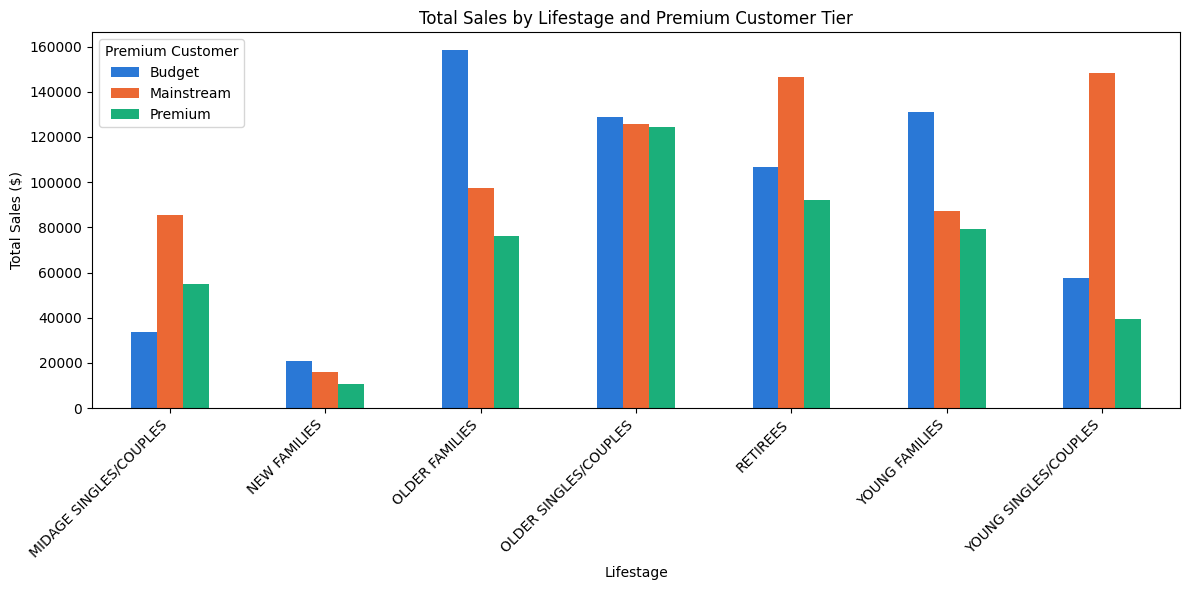

In [33]:
import matplotlib.pyplot as plt

# Pivot data for grouped bar chart
pivot_sales = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()

pivot_sales.plot(kind='bar', figsize=(12, 6), color=['#2a78d6', '#eb6834', '#1baf7a'])
plt.title('Total Sales by Lifestage and Premium Customer Tier')
plt.xlabel('Lifestage')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer')
plt.tight_layout()

plt.savefig('total_sales_by_segment.png', dpi=300)
plt.show()

# Sales by Pack size 

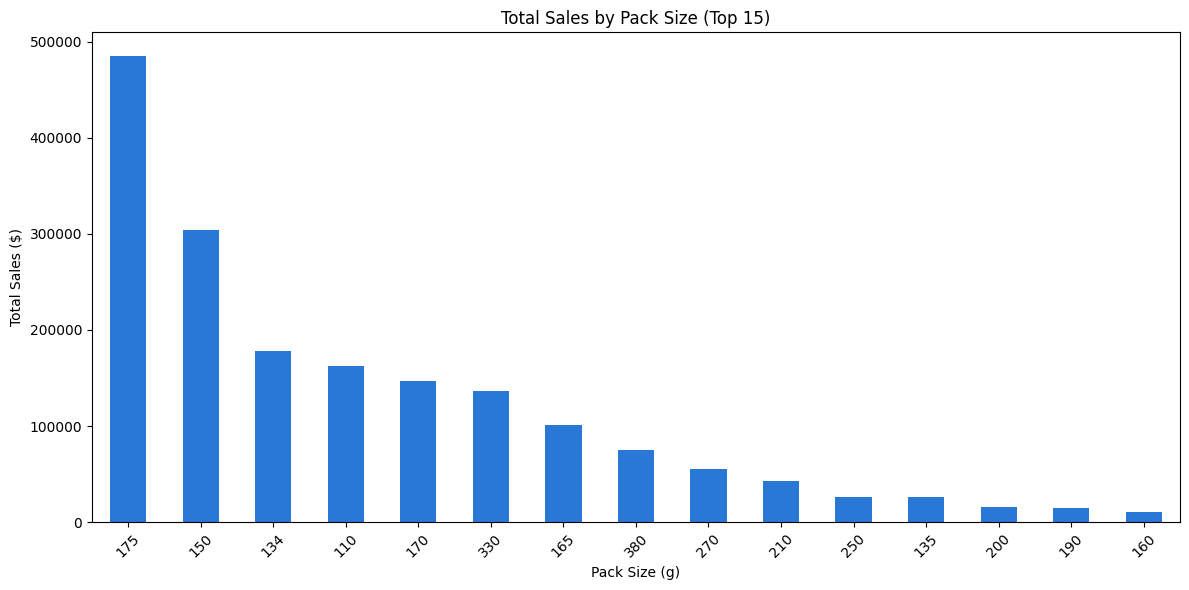

In [34]:
sales_by_pack = df_merged.groupby('PACK_SIZE')['TOT_SALES'].sum().sort_values(ascending=False)

sales_by_pack.head(15).plot(kind='bar', figsize=(12,6), color='#2a78d6')
plt.title('Total Sales by Pack Size (Top 15)')
plt.xlabel('Pack Size (g)')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_pack_size.png', dpi=300)
plt.show()

# Number of customers by segment

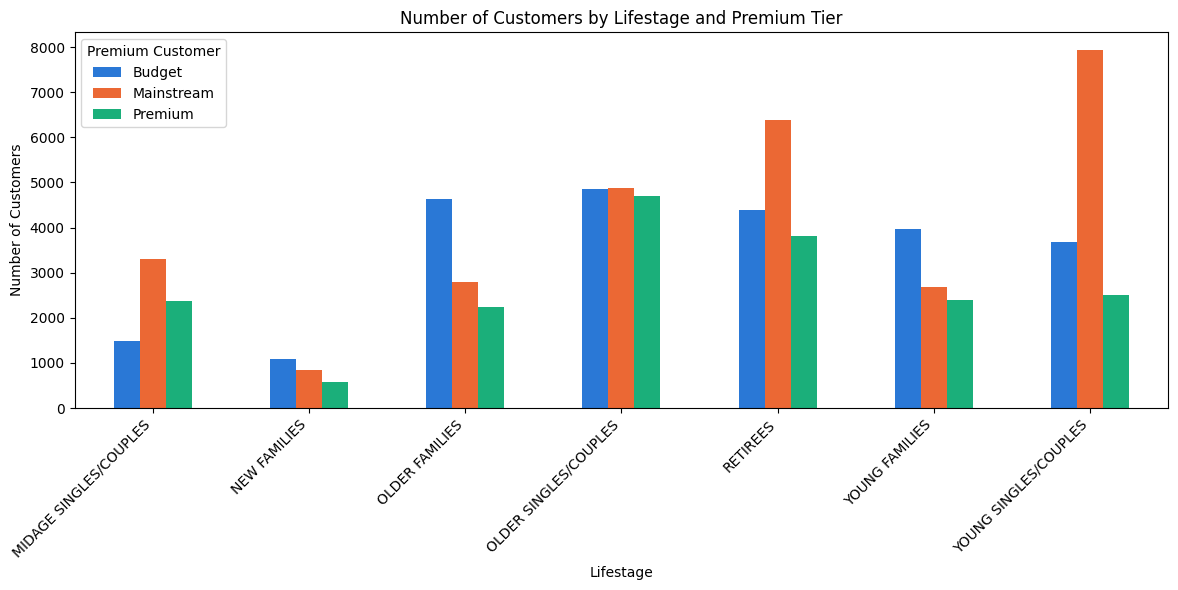

In [35]:
pivot_customers = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().unstack()

pivot_customers.plot(kind='bar', figsize=(12,6), color=['#2a78d6', '#eb6834', '#1baf7a'])
plt.title('Number of Customers by Lifestage and Premium Tier')
plt.xlabel('Lifestage')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer')
plt.tight_layout()
plt.savefig('customers_by_segment.png', dpi=300)
plt.show()

## Sales Trend Overtime

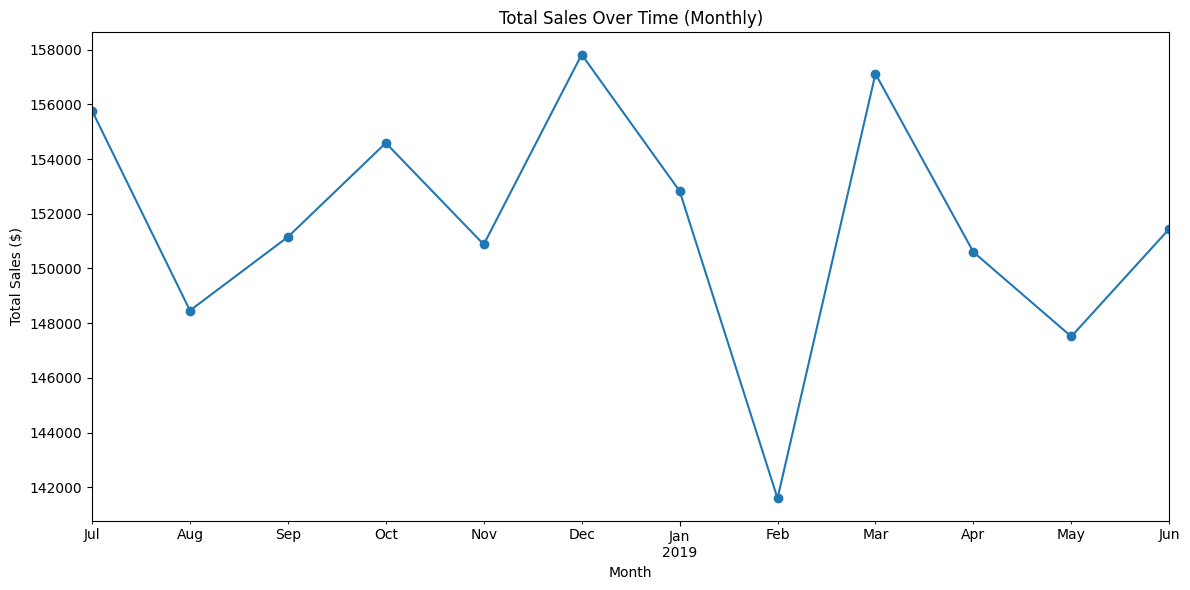

In [36]:
sales_over_time = df_merged.groupby(df_merged['DATE'].dt.to_period('M'))['TOT_SALES'].sum()

sales_over_time.plot(kind='line', figsize=(12,6), marker='o')

plt.title('Total Sales Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_over_time.png', dpi=300)
plt.show()

# Brand preferances by segment

In [37]:
# Extract brand as first word of PROD_NAME
df_merged['BRAND'] = df_merged['PROD_NAME'].str.split().str[0]

top_brands = df_merged.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False)
top_brands.head(10)

BRAND
Kettle       390239.8
Smiths       210076.8
Doritos      187277.9
Pringles     177655.5
Thins         88852.5
Twisties      81522.1
Tostitos      79789.6
Infuzions     76247.6
Cobs          70569.8
RRD           64954.5
Name: TOT_SALES, dtype: float64

# Store level concentration

In [38]:
sales_by_store = df_merged.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending=False)
sales_by_store.describe()

count      271.000000
mean      6715.071587
std       4417.925898
min          6.000000
25%       2787.675000
50%       5663.500000
75%      10362.200000
max      16544.650000
Name: TOT_SALES, dtype: float64

## Interesting Trends and Insights

**Seasonality**: Sales peak in December (~$157.8k) and again in March (~$157k), 
with a sharp dip in February (~$141.5k) — likely a post-holiday pullback after 
December/January spending.

**Brand performance**: Kettle is the dominant brand by total sales (~$390k), 
nearly 2x the next closest brand (Smiths, ~$210k).

**Store performance**: Sales are unevenly distributed across 271 stores 
(median ~$5.7k, mean ~$6.7k) — a small number of stores are driving a 
disproportionate share of total sales.

## Segments to Target

** Older Families - Budget — highest total sales, driven by high purchase frequency (~4.7 txns/customer). These are already loyal, frequent buyers. Strategy: retention — loyalty rewards, bulk-buy discounts, keep them buying at the same rate.
** Young Singles/Couples - Mainstream — 2nd highest sales, driven by a large customer base (~7,930, the biggest of any segment) but low frequency (~2.5 txns/customer). Strategy: frequency-building — promotions, targeted offers, or bundling to get this large base to buy more often, since even a small frequency increase here would move total sales significantly given the base size.
** Retirees - Mainstream — 3rd highest, large base (6,382) and healthy frequency (~3.15). Worth including as a stable, reliable secondary  target — not the top priority, but consistent.

## Is pack size relevant?

No. Average pack size across all 21 segments sits in a tight 173g-178g band — a 5g spread. Every segment, regardless of lifestage or spending tier, buys roughly the same pack size. Pack size is not a meaningful lever for segment targeting; marketing/promotion strategy should focus on frequency and loyalty instead, not on offering different pack sizes to different segments.

## Overall conclusion

** Chip category sales are driven more by customer volume and purchase frequency than by product traits like pack size or price
** Older Families - Budget and Young Singles/Couples - Mainstream are the top two revenue-driving segments — each getting there through a different path (frequency vs. customer base size)
** Pack size is not a useful targeting lever — average pack size is nearly identical (173g-178g) across all customer segments
** Kettle is the strongest-performing brand, suggesting brand preference matters more than pack size
** Sales show clear seasonality, peaking in December and March, dipping in February
** Sales are concentrated in a subset of stores rather than evenly spread across all 271 locations

## Task 2 - Trial Store Impact Analysis

In [39]:
df_merged['YEARMONTH'] = df_merged['DATE'].dt.to_period('M')

monthly_store = df_merged.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    total_sales=('TOT_SALES', 'sum'),
    total_customers=('LYLTY_CARD_NBR', 'nunique'),
    total_txns=('TXN_ID', 'nunique')
).reset_index()
monthly_store['txns_per_customer'] = monthly_store['total_txns'] / monthly_store['total_customers']

print(monthly_store.shape)
monthly_store.head()

(3166, 6)


,STORE_NBR,YEARMONTH,total_sales,total_customers,total_txns,txns_per_customer
0,1,2018-07,191.6,48,50,1.041667
1,1,2018-08,168.4,41,41,1.000000
2,1,2018-09,268.1,57,59,1.035088
3,1,2018-10,178.0,40,41,1.025000
4,1,2018-11,187.5,45,46,1.022222


In [40]:
# Count how many distinct months each store has data for
months_per_store = monthly_store.groupby('STORE_NBR')['YEARMONTH'].nunique()

In [41]:
# Keeping only stores with exactly 12 months (July 2018 - June 2019)
full_year_stores = months_per_store[months_per_store == 12].index

monthly_store_full = monthly_store[monthly_store['STORE_NBR'].isin(full_year_stores)]

print(f"Total stores: {monthly_store['STORE_NBR'].nunique()}")
print(f"Stores with full 12 months: {len(full_year_stores)}")

Total stores: 271
Stores with full 12 months: 259


In [42]:
pre_trial_months = pd.period_range('2018-07', '2019-01', freq='M')
pre_trial_data = monthly_store_full[monthly_store_full['YEARMONTH'].isin(pre_trial_months)]

In [43]:
def calc_similarity(trial_store, metric, pre_trial_data):
    """
    For a given trial store and a given metric (e.g. total_sales),
    score every other store on how similar its monthly pattern is.
    """
    trial_series = pre_trial_data[pre_trial_data['STORE_NBR'] == trial_store].set_index('YEARMONTH')[metric]
    
    results = []
    for store in pre_trial_data['STORE_NBR'].unique():
        if store == trial_store:
            continue
        control_series = pre_trial_data[pre_trial_data['STORE_NBR'] == store].set_index('YEARMONTH')[metric]
        
        # Only compare months both stores actually have
        common_months = trial_series.index.intersection(control_series.index)
        if len(common_months) < 5:
            continue  # not enough overlap to trust this comparison
        
        t = trial_series.loc[common_months]
        c = control_series.loc[common_months]
        
        # 1. Pattern match: correlation (closer to 1 = moves the same way over time)
        correlation = t.corr(c)
        
        # 2. Size match: how far apart are they, on average, as a % of their size?
        pct_diff = (abs(t - c) / ((t + c) / 2)).mean()
        magnitude_score = 1 - pct_diff  # flip it so higher = more similar (matches correlation's direction)
        
        # Combine both into one score, weighted equally
        combined_score = (correlation + magnitude_score) / 2
        
        results.append({
            'STORE_NBR': store,
            'correlation': round(correlation, 3),
            'magnitude_score': round(magnitude_score, 3),
            'combined_score': round(combined_score, 3)
        })
    
    return pd.DataFrame(results).sort_values('combined_score', ascending=False)

In [44]:
ranking = calc_similarity(77, 'total_sales', pre_trial_data)
ranking.head()

,STORE_NBR,correlation,magnitude_score,combined_score
219,233,0.977,0.902,0.939
46,50,0.918,0.892,0.905
38,41,0.820,0.759,0.790
49,53,0.575,0.828,0.702
178,188,0.496,0.892,0.694


In [45]:
ranking = calc_similarity(86, 'total_sales', pre_trial_data)
ranking.head()

,STORE_NBR,correlation,magnitude_score,combined_score
146,155,0.852,0.961,0.907
106,114,0.798,0.939,0.868
208,222,0.773,0.942,0.857
129,138,0.770,0.942,0.856
254,269,0.779,0.920,0.849


In [46]:
ranking = calc_similarity(88, 'total_sales', pre_trial_data)
ranking.head()

,STORE_NBR,correlation,magnitude_score,combined_score
84,91,0.912,0.586,0.749
74,79,0.772,0.720,0.746
6,7,0.699,0.756,0.727
190,201,0.484,0.869,0.676
116,125,0.453,0.841,0.647


In [47]:
control_store_map = {77: 233, 86: 155, 88: 91}

def scale_control_store(trial_store, control_store, metric, monthly_data, pre_trial_months):
    trial = monthly_data[monthly_data['STORE_NBR'] == trial_store].set_index('YEARMONTH')[metric]
    control = monthly_data[monthly_data['STORE_NBR'] == control_store].set_index('YEARMONTH')[metric]
    
    # Scaling factor = trial store's pre-trial average / control store's pre-trial average
    scaling_factor = trial.loc[pre_trial_months].mean() / control.loc[pre_trial_months].mean()
    
    scaled_control = control * scaling_factor
    return trial, scaled_control, scaling_factor

In [48]:
import numpy as np
from scipy import stats

def assess_trial_significance(trial_store, control_store, metric, monthly_data, pre_trial_months, trial_months):
    trial, scaled_control, scaling_factor = scale_control_store(
        trial_store, control_store, metric, monthly_data, pre_trial_months
    )
    
    # % difference each month: (trial - control) / control
    pct_diff = (trial - scaled_control) / scaled_control * 100
    
    # Use PRE-trial months only to measure "normal" noise
    pre_trial_std = pct_diff.loc[pre_trial_months].std()
    degrees_freedom = len(pre_trial_months) - 1
    
    # 95% confidence t-critical value
    t_critical = stats.t.ppf(0.95, degrees_freedom)
    
    print(f"\n=== Trial Store {trial_store} vs Control Store {control_store} ({metric}) ===")
    print(f"Scaling factor applied to control: {scaling_factor:.3f}")
    print(f"Pre-trial noise (std dev of % diff): {pre_trial_std:.2f}%")
    print(f"t-critical (95% confidence): {t_critical:.3f}\n")
    
    for month in trial_months:
        diff = pct_diff.loc[month]
        t_value = diff / pre_trial_std
        significant = "YES — significant" if t_value > t_critical else "no"
        print(f"{month}: % difference = {diff:+.1f}%, t-value = {t_value:.2f}  -> {significant}")
    
    return trial, scaled_control, pct_diff

In [49]:
pre_trial_months = pd.period_range('2018-07', '2019-01', freq='M')
trial_months = pd.period_range('2019-02', '2019-04', freq='M')

results = {}
for trial_store, control_store in control_store_map.items():
    trial, scaled_control, pct_diff = assess_trial_significance(
        trial_store, control_store, 'total_sales', monthly_store_full, pre_trial_months, trial_months
    )
    results[trial_store] = {'trial': trial, 'scaled_control': scaled_control, 'pct_diff': pct_diff}


=== Trial Store 77 vs Control Store 233 (total_sales) ===
Scaling factor applied to control: 1.049
Pre-trial noise (std dev of % diff): 14.14%
t-critical (95% confidence): 1.943

2019-02: % difference = -7.4%, t-value = -0.52  -> no
2019-03: % difference = +34.6%, t-value = 2.45  -> YES — significant
2019-04: % difference = +74.1%, t-value = 5.24  -> YES — significant

=== Trial Store 86 vs Control Store 155 (total_sales) ===
Scaling factor applied to control: 0.974
Pre-trial noise (std dev of % diff): 4.32%
t-critical (95% confidence): 1.943

2019-02: % difference = +5.3%, t-value = 1.22  -> no
2019-03: % difference = +26.1%, t-value = 6.03  -> YES — significant
2019-04: % difference = +3.1%, t-value = 0.72  -> no

=== Trial Store 88 vs Control Store 91 (total_sales) ===
Scaling factor applied to control: 1.521
Pre-trial noise (std dev of % diff): 3.11%
t-critical (95% confidence): 1.943

2019-02: % difference = +7.0%, t-value = 2.25  -> YES — significant
2019-03: % difference = +16.

### Store 77
- Sales were flat in February, but jumped significantly in March and April
- By April, sales were 74% higher than the control store — the strongest result of the three
- Suggests the new layout took a little time to start working, then had a big effect

### Store 86
- Sales spiked significantly in March, but not in February or April
- Looks like a short-term boost rather than a lasting change

### Store 88
- Sales rose significantly in February and March, but faded by April
- Customers responded quickly, but the effect didn't last the full trial

### Overall Conclusion
All three trial stores showed at least one month of real, significant sales increase — 
so the new layout does seem to be working. But the effect shows up at different times 
and doesn't last the same way in every store, so it's not a simple "yes it works everywhere, 
all the time" result.

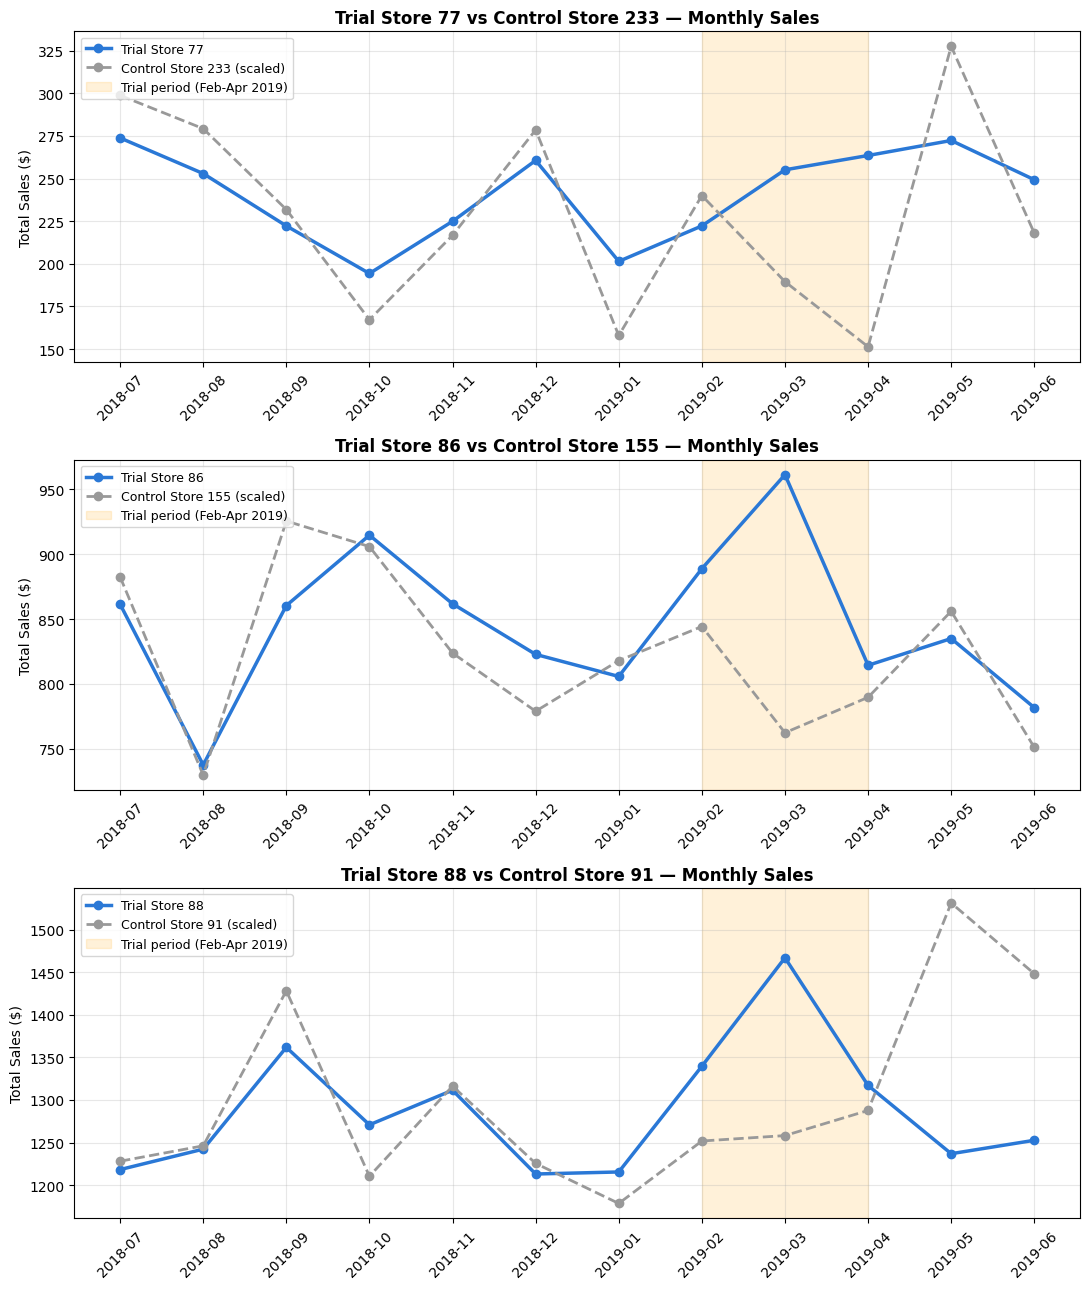

In [50]:
import matplotlib.pyplot as plt

def scale_control_store(trial_store, control_store, metric, monthly_data, pre_trial_months):
    trial = monthly_data[monthly_data['STORE_NBR'] == trial_store].set_index('YEARMONTH')[metric]
    control = monthly_data[monthly_data['STORE_NBR'] == control_store].set_index('YEARMONTH')[metric]
    scaling_factor = trial.loc[pre_trial_months].mean() / control.loc[pre_trial_months].mean()
    scaled_control = control * scaling_factor
    return trial, scaled_control, scaling_factor

control_store_map = {77: 233, 86: 155, 88: 91}
pre_trial_months = pd.period_range('2018-07', '2019-01', freq='M')
trial_months = pd.period_range('2019-02', '2019-04', freq='M')

fig, axes = plt.subplots(3, 1, figsize=(11, 13))

for ax, (trial_store, control_store) in zip(axes, control_store_map.items()):
    trial, scaled_control, sf = scale_control_store(
        trial_store, control_store, 'total_sales', monthly_store_full, pre_trial_months
    )
    
    x = trial.index.astype(str)
    ax.plot(x, trial.values, marker='o', label=f'Trial Store {trial_store}', color='#2a78d6', linewidth=2.5)
    ax.plot(x, scaled_control.values, marker='o', label=f'Control Store {control_store} (scaled)', 
            color='#999999', linewidth=2, linestyle='--')
    
    # Shade the trial period so it's visually obvious
    trial_start_idx = list(trial.index).index(trial_months[0])
    trial_end_idx = list(trial.index).index(trial_months[-1])
    ax.axvspan(trial_start_idx, trial_end_idx, color='orange', alpha=0.15, label='Trial period (Feb-Apr 2019)')
    
    ax.set_title(f'Trial Store {trial_store} vs Control Store {control_store} — Monthly Sales', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Total Sales ($)')
    ax.legend(loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trial_vs_control_all.png', dpi=150)
plt.show()

In [51]:
# Monthly metrics for reference
monthly_store_full.to_csv('monthly_store_metrics.csv', index=False)

# Control store mapping
pd.DataFrame(list(control_store_map.items()), columns=['Trial_Store', 'Control_Store']).to_csv('control_store_selection.csv', index=False)